# Configuração Inicial e Imports

Esta célula importa todas as bibliotecas necessárias e define os parâmetros globais do projeto:

- **WINDOW**: Tamanho da janela temporal (240 pontos)
- **STRIDE**: Passo entre janelas (1000 pontos)
- **DATASET_PATHS**: Caminhos para os 7 arquivos de dados
- **GLOBAL_MEAN/STD**: Estatísticas globais para normalização dos sensores

Os imports incluem TensorFlow para deep learning, scikit-learn para métricas de avaliação, e bibliotecas padrão para manipulação de dados.

In [2]:
# Imports
import pandas as pd
import numpy as np
import glob
import tensorflow as tf
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os

# Parâmetros globais
WINDOW = 240
STRIDE = 1000
SAMPLING_RATE = 1
DATASET_PATHS = [
    '/content/dataset_parte_1.csv', '/content/dataset_parte_2.csv',
    '/content/dataset_parte_3.csv', '/content/dataset_parte_4.csv',
    '/content/dataset_parte_5.csv', '/content/dataset_parte_6.csv',
    '/content/dataset_parte_7.csv'
]

# Estatísticas globais (do enunciado)
GLOBAL_MEAN = 31.9291
GLOBAL_STD = (319.5190 - (-29.3986)) / 1.349  # Approx usando IQR / 1.349


# Analise Exeploratoria

/tmp/ipython-input-2854920450.py:5: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('/content/dataset_parte_1.csv')
/tmp/ipython-input-2854920450.py:42: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label=f'{col} anomaly')
/tmp/ipython-input-2854920450.py:71: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2854920450.py:71: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2854920450.py:71: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2854920450.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes 

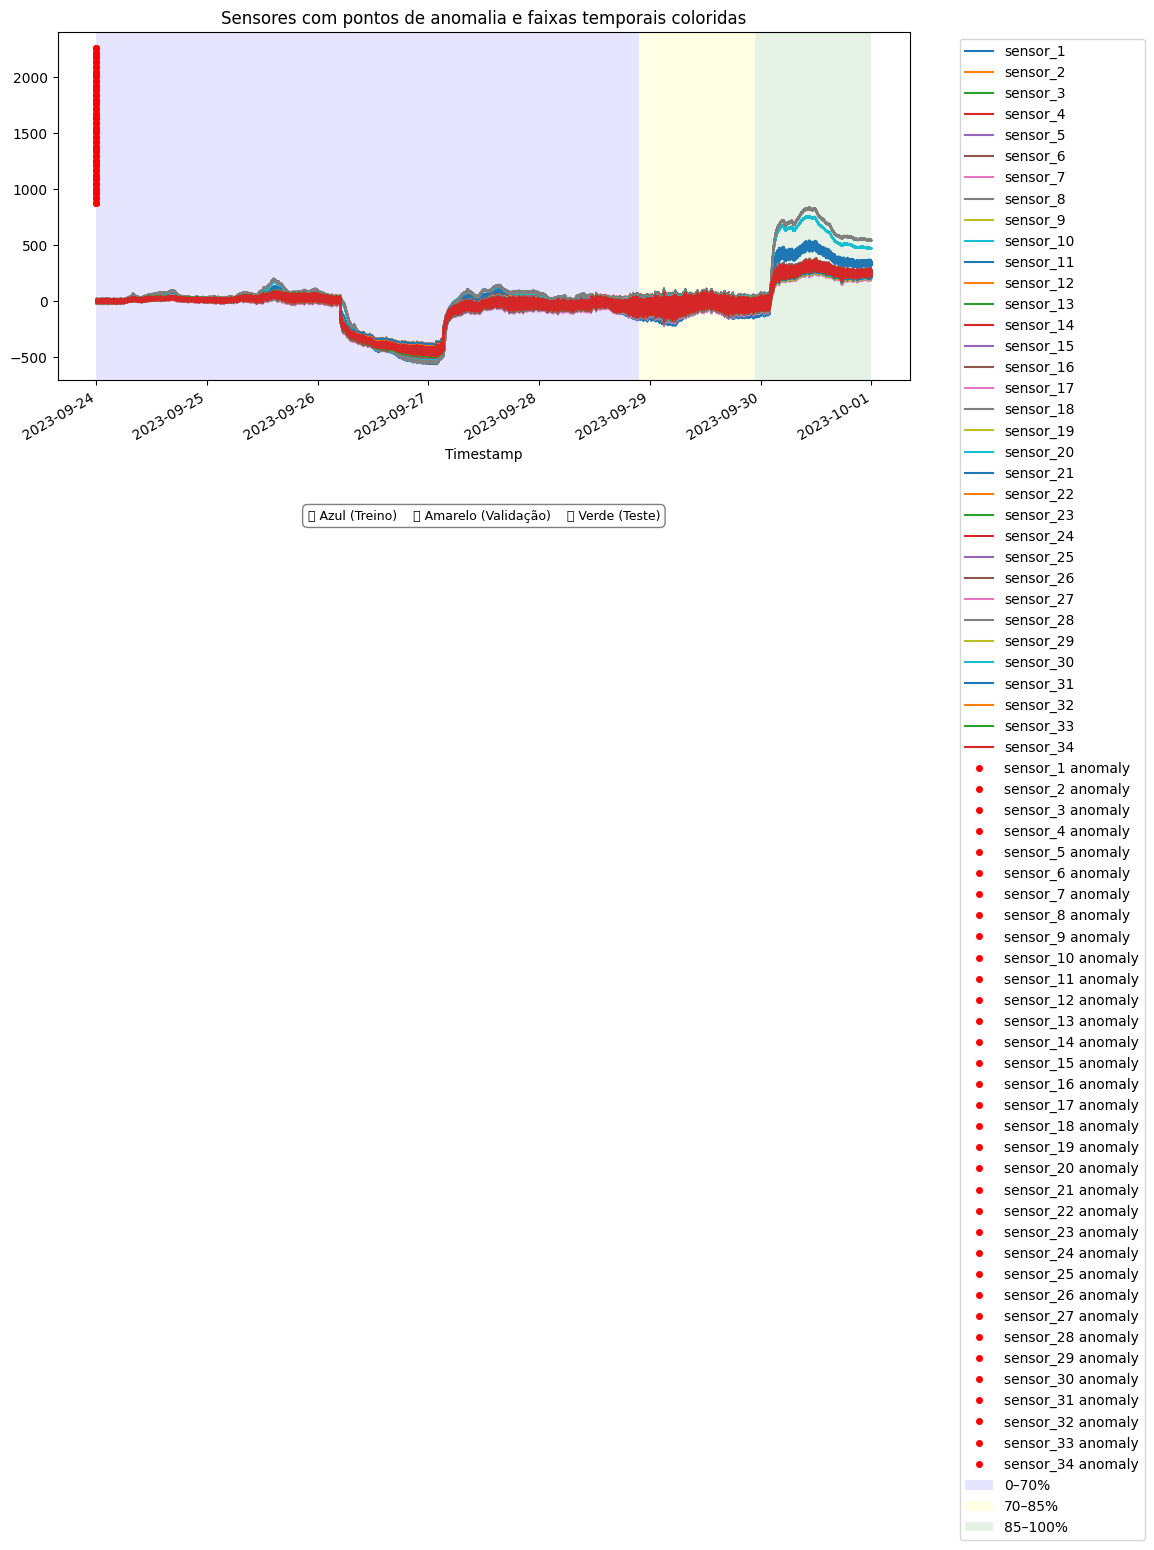

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Leitura dos arquivos CSV
df1 = pd.read_csv('/content/dataset_parte_1.csv')
df2 = pd.read_csv('/content/dataset_parte_2.csv')
df3 = pd.read_csv('/content/dataset_parte_3.csv')
df4 = pd.read_csv('/content/dataset_parte_4.csv')
df5 = pd.read_csv('/content/dataset_parte_5.csv')
df6 = pd.read_csv('/content/dataset_parte_6.csv')
df7 = pd.read_csv('/content/dataset_parte_7.csv')

# Concatenação dos dados
data = pd.concat([df1, df2, df3, df4, df5, df6, df7], ignore_index=True)

# Conversão do timestamp e configuração do índice
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data.set_index('Timestamp', inplace=True)

# Criação da coluna label_binary
data['label_binary'] = data['label'].notna().astype(int)

# Remoção da coluna 'label'
data = data.drop('label', axis=1)

# Definir colunas dos sensores
sensor_columns = [col for col in data.columns if col != 'label_binary']

# Plot dos sensores
fig, ax = plt.subplots(figsize=(11,6))
data[sensor_columns].plot(ax=ax)

# Anomalias
anomaly_points = data[data['label_binary'] == 1]
max_val = data[sensor_columns].max().max()
y_offset_base = max_val * 0.05

# Adicionar pontos vermelhos elevados
for i, col in enumerate(sensor_columns):
    y_offset = y_offset_base * (i + 1)
    y_pos = [max_val + y_offset] * len(anomaly_points)
    ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label=f'{col} anomaly')

# Divisão do eixo X em 70/15/15%
timestamps = data.index
n = len(timestamps)
t1 = timestamps[int(n * 0.7)]
t2 = timestamps[int(n * 0.85)]
t3 = timestamps[-1]

# Faixas coloridas no fundo do gráfico
ax.axvspan(timestamps[0], t1, facecolor='blue', alpha=0.1, label='0–70%')
ax.axvspan(t1, t2, facecolor='yellow', alpha=0.1, label='70–85%')
ax.axvspan(t2, t3, facecolor='green', alpha=0.1, label='85–100%')

# Ajuste da legenda para evitar duplicatas
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

# Caixa explicativa abaixo do gráfico
ax.text(0.5, -0.40,
        '🟦 Azul (Treino)    🟨 Amarelo (Validação)    🟩 Verde (Teste)',
        transform=ax.transAxes,
        fontsize=9,
        ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray'))


plt.title('Sensores com pontos de anomalia e faixas temporais coloridas')
plt.tight_layout()
plt.subplots_adjust(bottom=0.3) # Add space for the text box
plt.show()

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

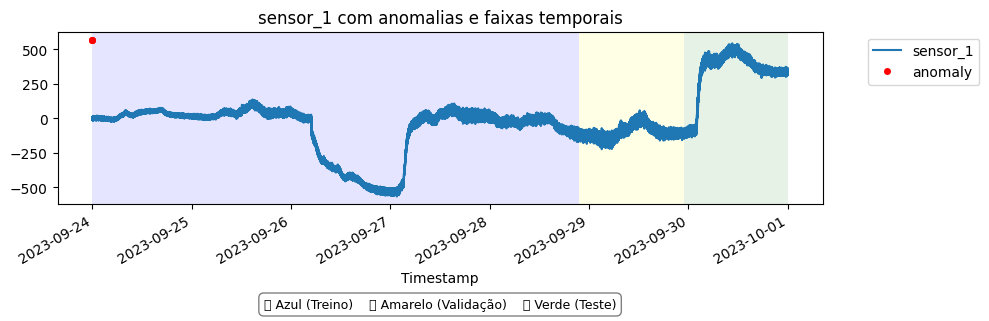

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

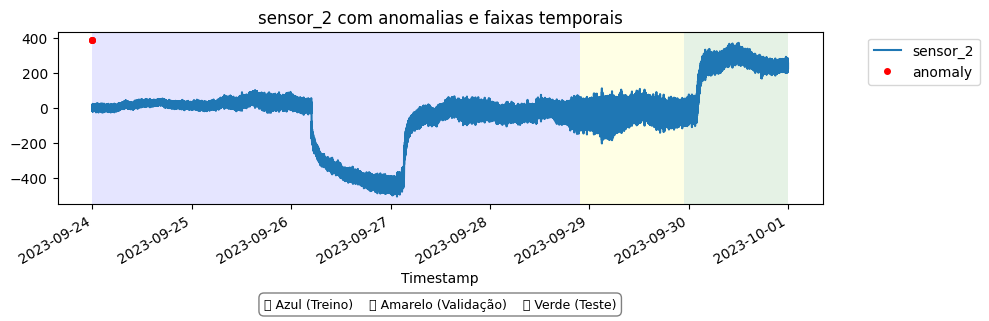

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

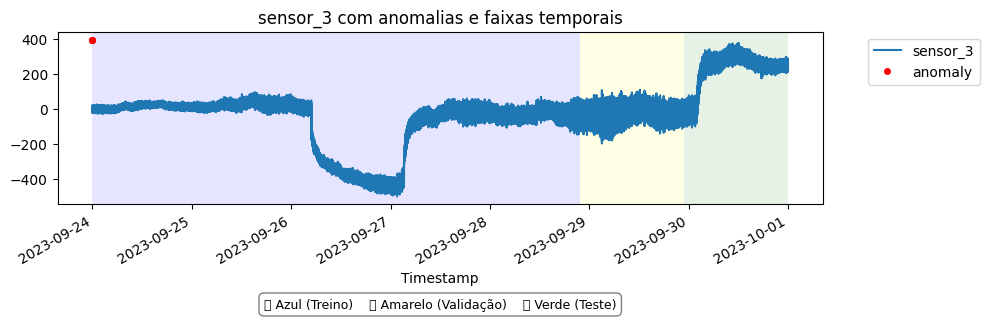

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

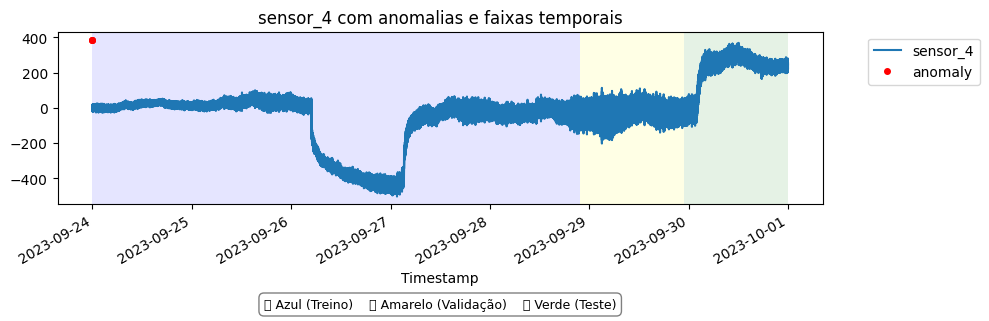

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

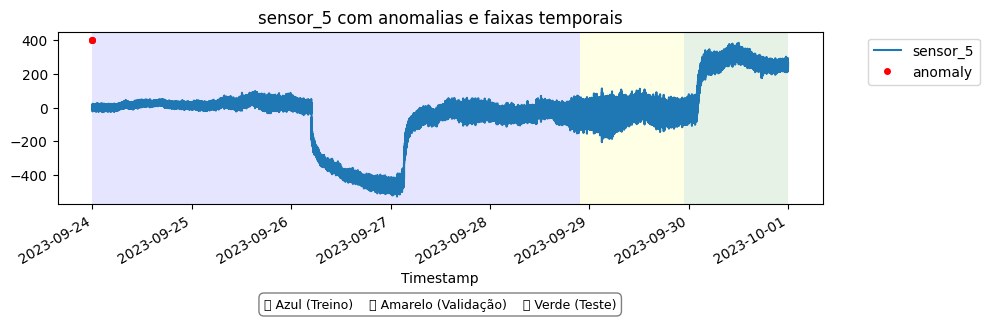

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

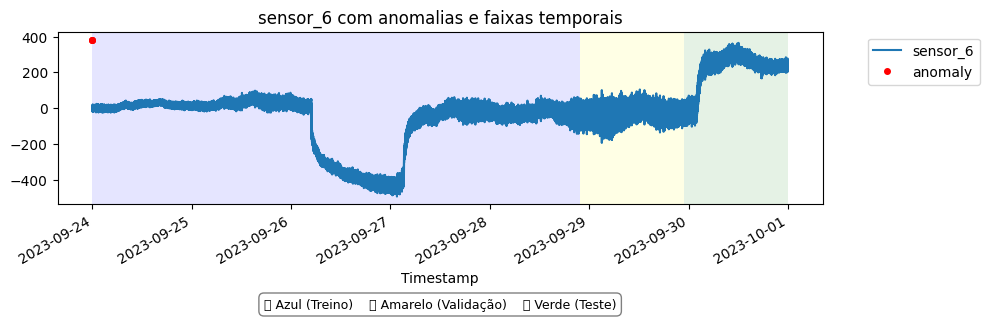

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

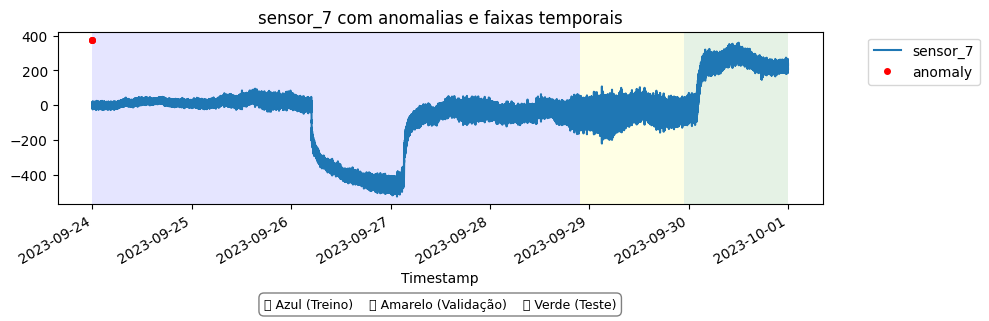

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

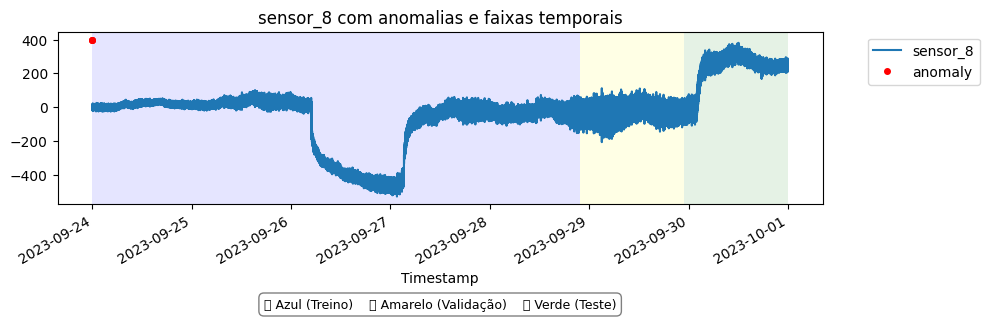

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

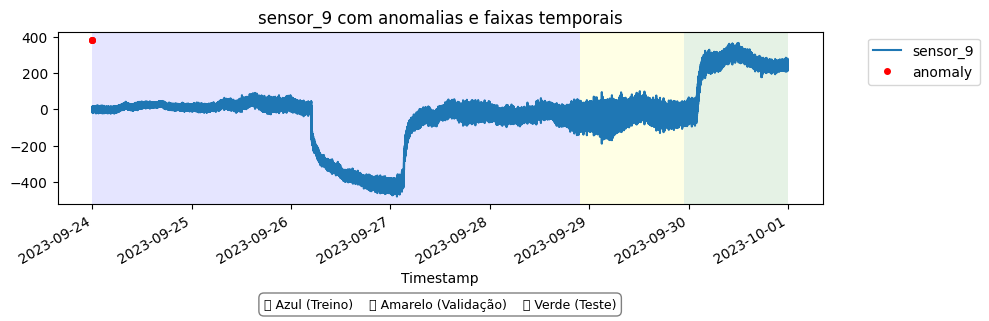

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

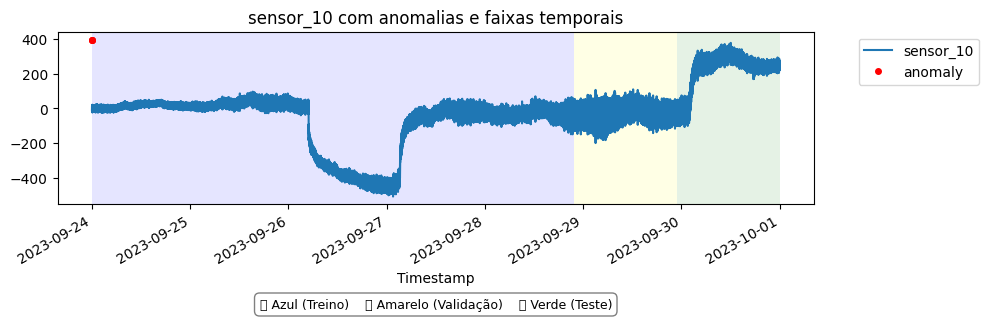

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

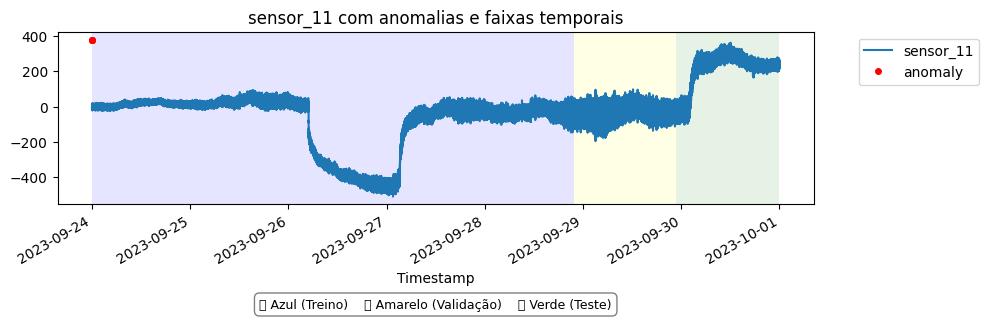

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

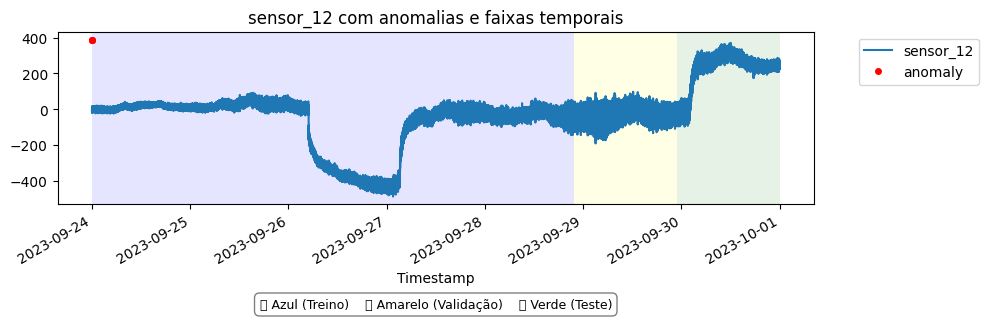

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

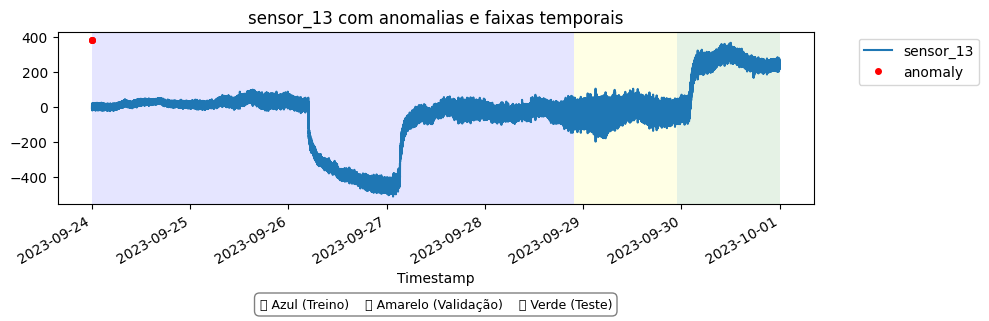

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

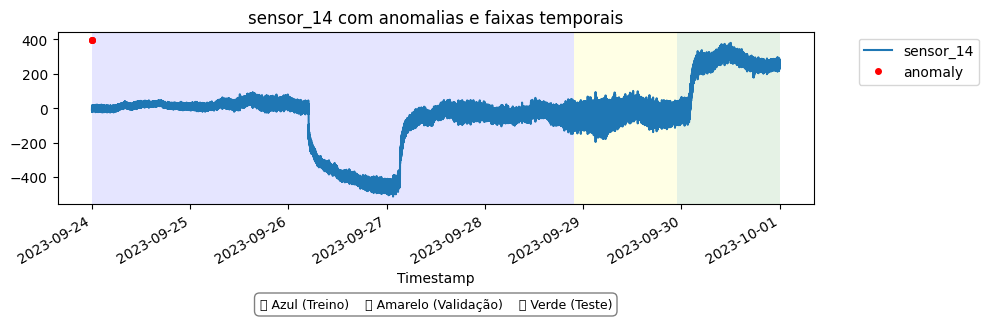

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

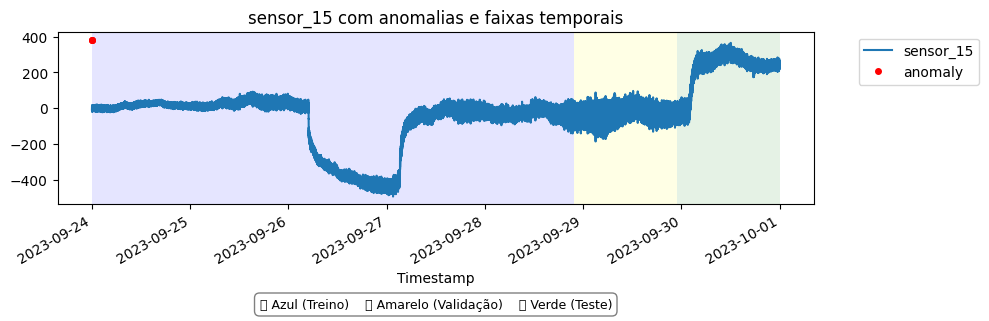

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

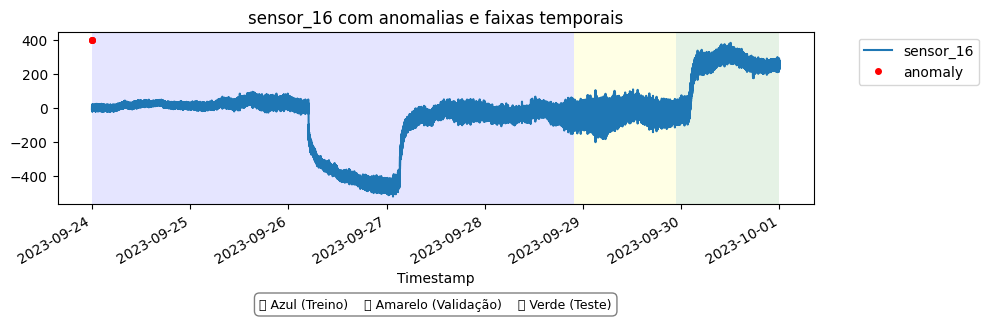

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

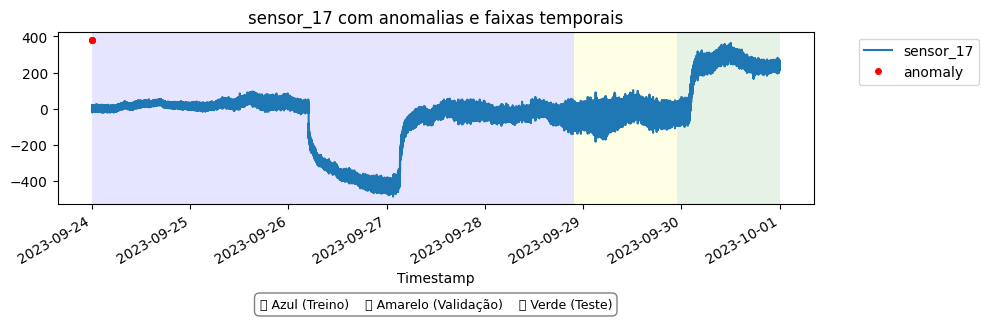

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

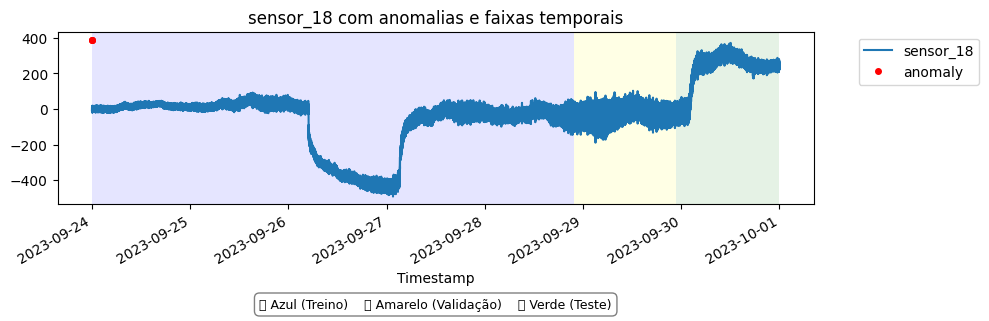

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

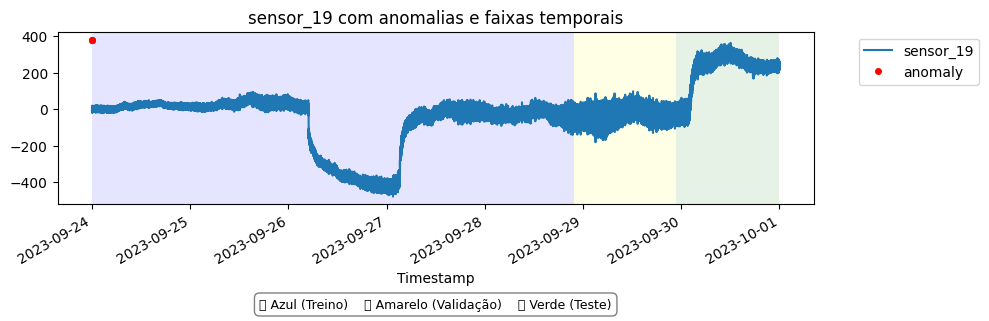

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

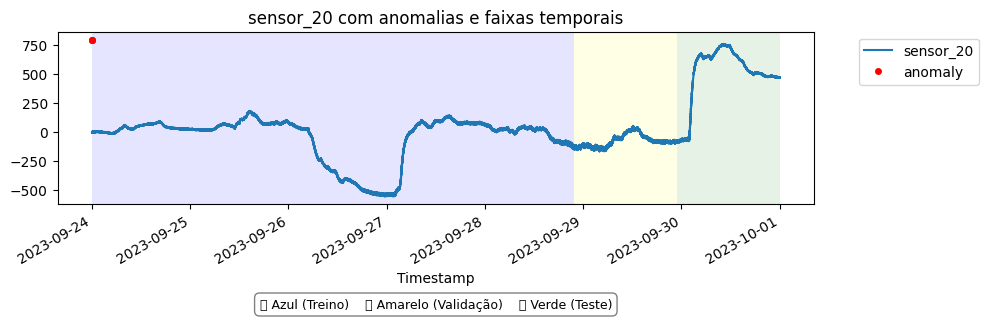

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

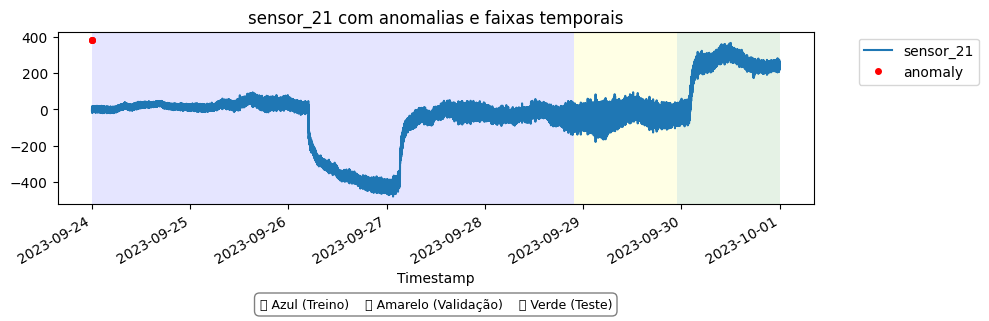

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

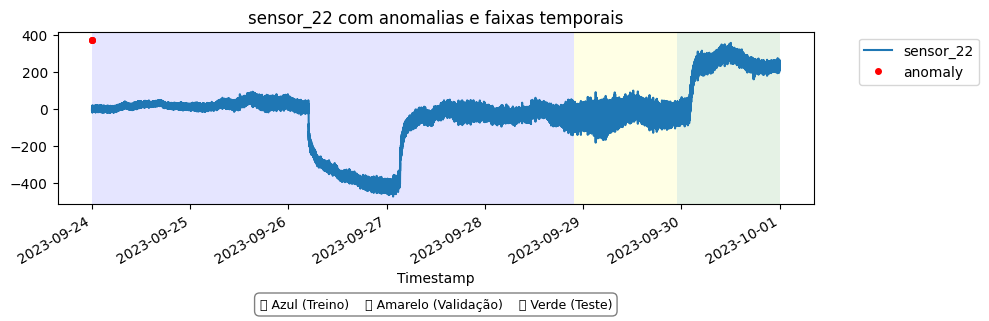

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

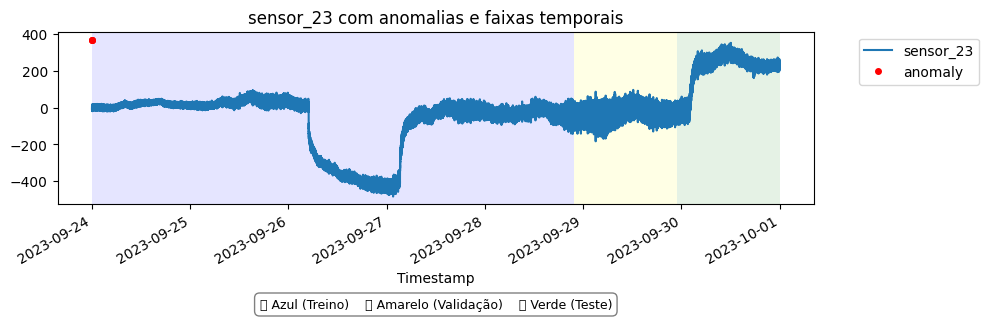

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

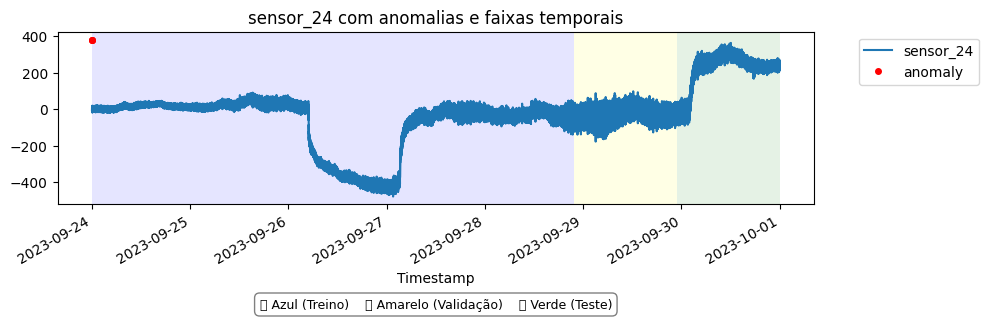

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

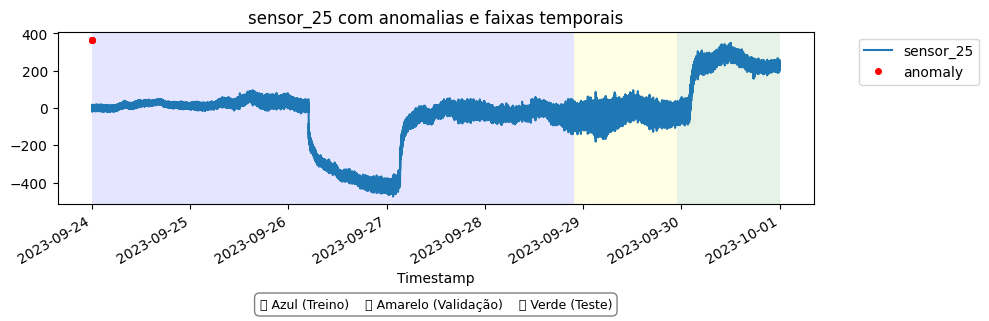

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

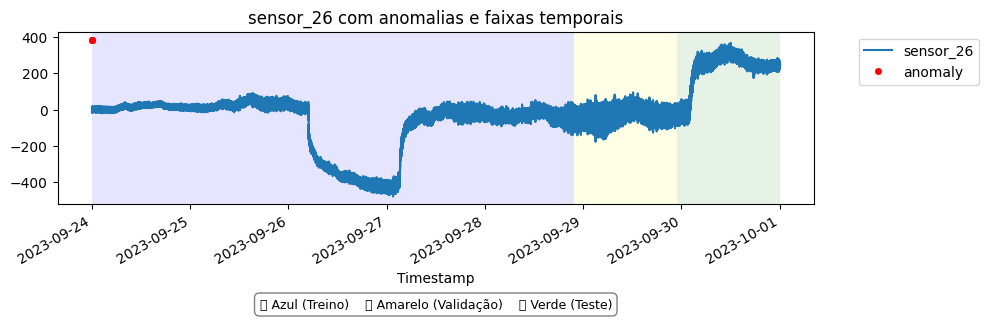

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

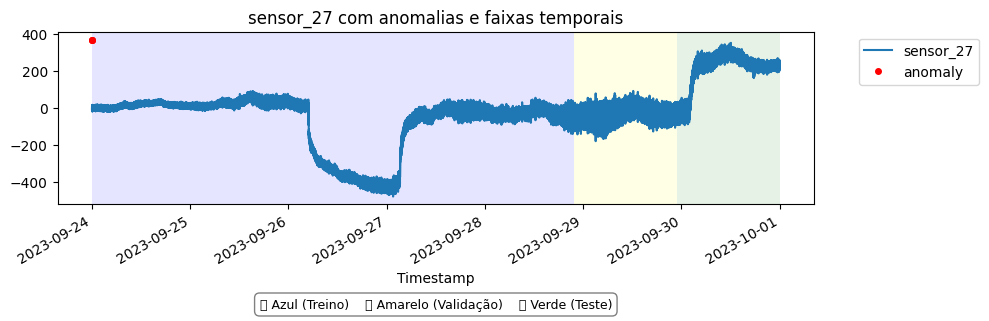

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

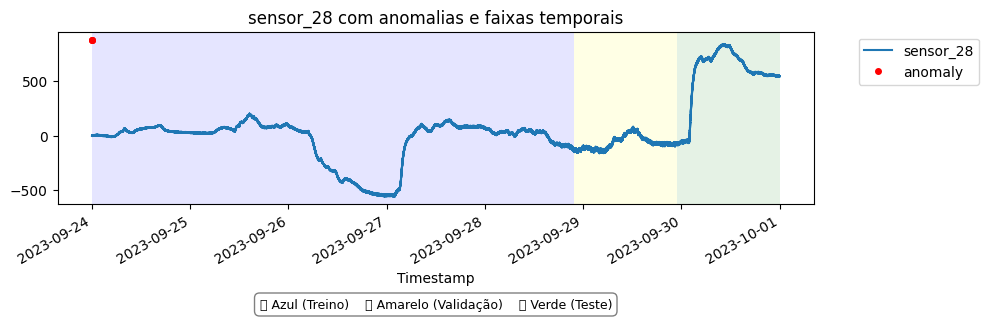

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

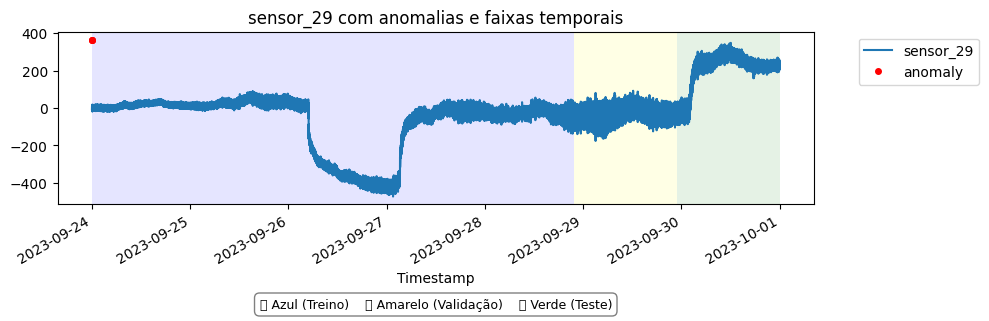

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

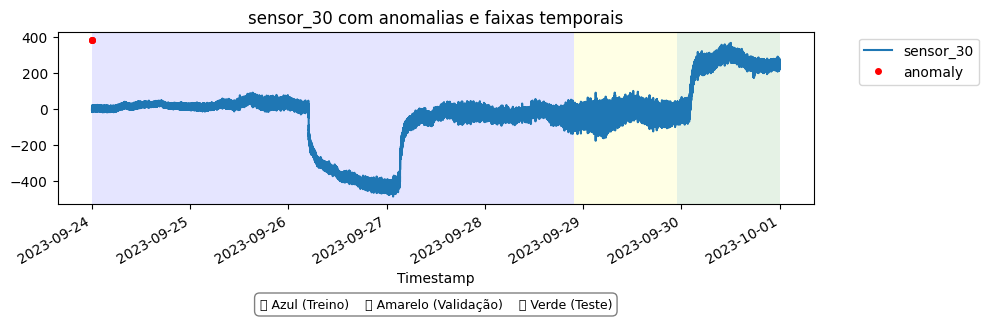

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

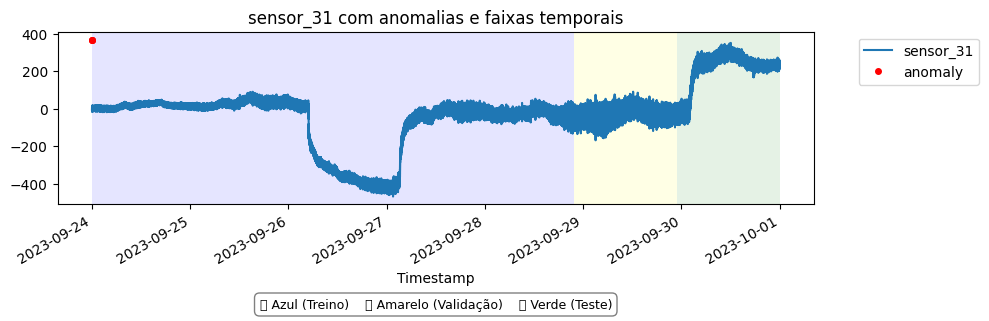

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

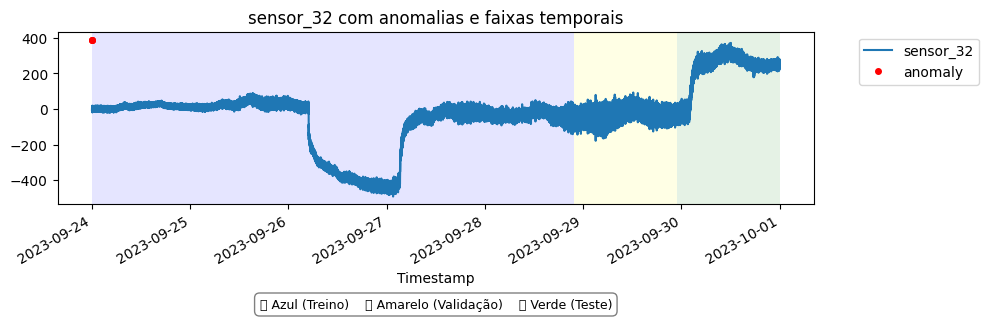

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

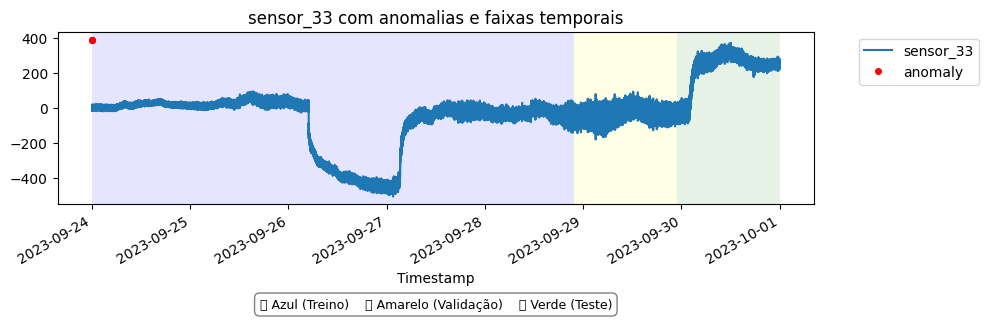

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

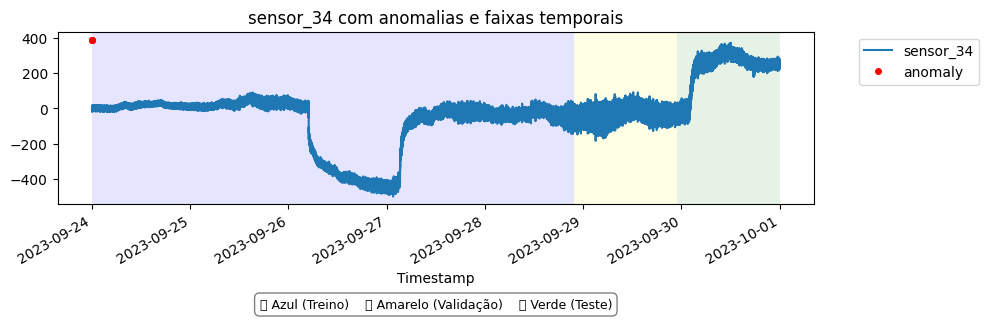

In [23]:
for i in range(1, 35):
    sensor_name = f'sensor_{i}'
    if sensor_name not in data.columns:
        continue  # pular se o sensor não existir

    fig, ax = plt.subplots(figsize=(10, 3))

    # Plot do sensor
    data[sensor_name].plot(ax=ax, label=sensor_name)

    # Valor máximo para deslocar os pontos vermelhos
    max_val = data[sensor_name].max()
    y_offset = max_val * 0.05
    y_pos = [max_val + y_offset] * len(anomaly_points)

    # Plot dos pontos vermelhos
    ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')

    # Faixas coloridas
    ax.axvspan(timestamps[0], t1, facecolor='blue', alpha=0.1)
    ax.axvspan(t1, t2, facecolor='yellow', alpha=0.1)
    ax.axvspan(t2, t3, facecolor='green', alpha=0.1)

    # Título e legenda
    ax.set_title(f'{sensor_name} com anomalias e faixas temporais')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Caixa explicativa abaixo do gráfico
    ax.text(0.5, -0.60,
            '🟦 Azul (Treino)    🟨 Amarelo (Validação)    🟩 Verde (Teste)',
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray'))

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)  # Espaço extra abaixo do gráfico para a caixa
    plt.show()


# Analise Exeploratoria

/tmp/ipython-input-2854920450.py:5: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('/content/dataset_parte_1.csv')
/tmp/ipython-input-2854920450.py:42: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label=f'{col} anomaly')
/tmp/ipython-input-2854920450.py:71: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2854920450.py:71: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2854920450.py:71: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2854920450.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes 

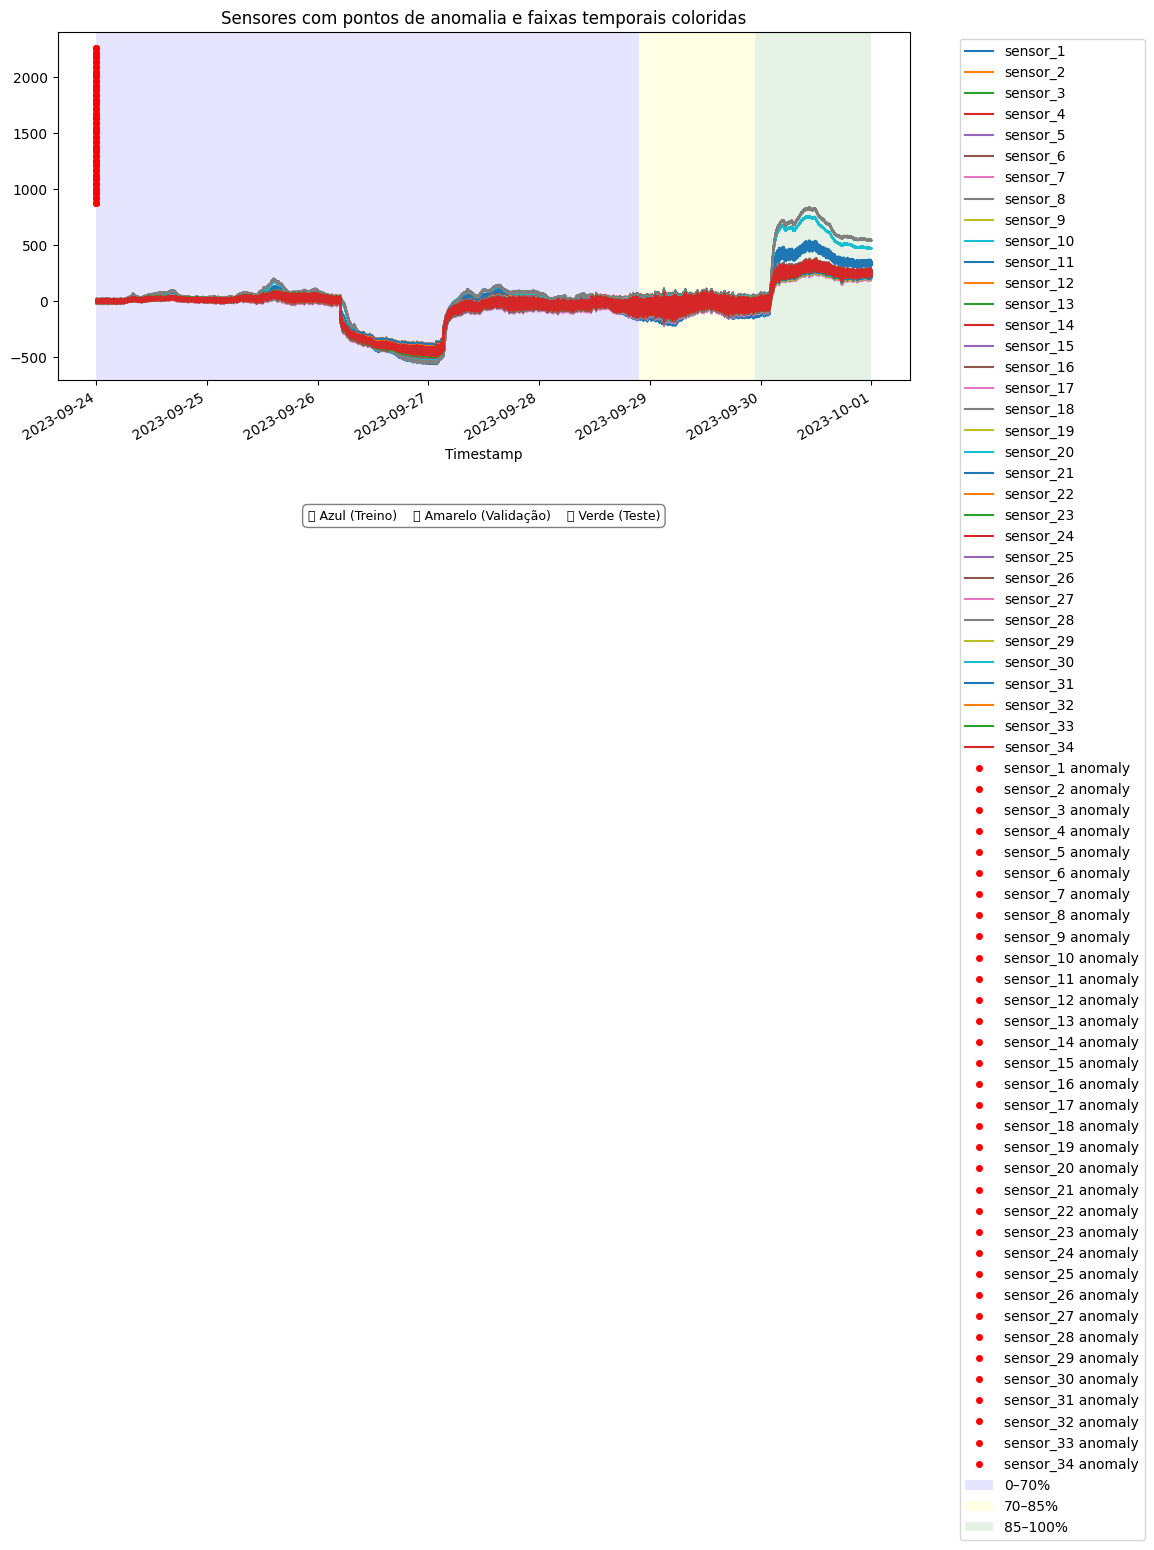

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Leitura dos arquivos CSV
df1 = pd.read_csv('/content/dataset_parte_1.csv')
df2 = pd.read_csv('/content/dataset_parte_2.csv')
df3 = pd.read_csv('/content/dataset_parte_3.csv')
df4 = pd.read_csv('/content/dataset_parte_4.csv')
df5 = pd.read_csv('/content/dataset_parte_5.csv')
df6 = pd.read_csv('/content/dataset_parte_6.csv')
df7 = pd.read_csv('/content/dataset_parte_7.csv')

# Concatenação dos dados
data = pd.concat([df1, df2, df3, df4, df5, df6, df7], ignore_index=True)

# Conversão do timestamp e configuração do índice
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data.set_index('Timestamp', inplace=True)

# Criação da coluna label_binary
data['label_binary'] = data['label'].notna().astype(int)

# Remoção da coluna 'label'
data = data.drop('label', axis=1)

# Definir colunas dos sensores
sensor_columns = [col for col in data.columns if col != 'label_binary']

# Plot dos sensores
fig, ax = plt.subplots(figsize=(11,6))
data[sensor_columns].plot(ax=ax)

# Anomalias
anomaly_points = data[data['label_binary'] == 1]
max_val = data[sensor_columns].max().max()
y_offset_base = max_val * 0.05

# Adicionar pontos vermelhos elevados
for i, col in enumerate(sensor_columns):
    y_offset = y_offset_base * (i + 1)
    y_pos = [max_val + y_offset] * len(anomaly_points)
    ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label=f'{col} anomaly')

# Divisão do eixo X em 70/15/15%
timestamps = data.index
n = len(timestamps)
t1 = timestamps[int(n * 0.7)]
t2 = timestamps[int(n * 0.85)]
t3 = timestamps[-1]

# Faixas coloridas no fundo do gráfico
ax.axvspan(timestamps[0], t1, facecolor='blue', alpha=0.1, label='0–70%')
ax.axvspan(t1, t2, facecolor='yellow', alpha=0.1, label='70–85%')
ax.axvspan(t2, t3, facecolor='green', alpha=0.1, label='85–100%')

# Ajuste da legenda para evitar duplicatas
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

# Caixa explicativa abaixo do gráfico
ax.text(0.5, -0.40,
        '🟦 Azul (Treino)    🟨 Amarelo (Validação)    🟩 Verde (Teste)',
        transform=ax.transAxes,
        fontsize=9,
        ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray'))


plt.title('Sensores com pontos de anomalia e faixas temporais coloridas')
plt.tight_layout()
plt.subplots_adjust(bottom=0.3) # Add space for the text box
plt.show()

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

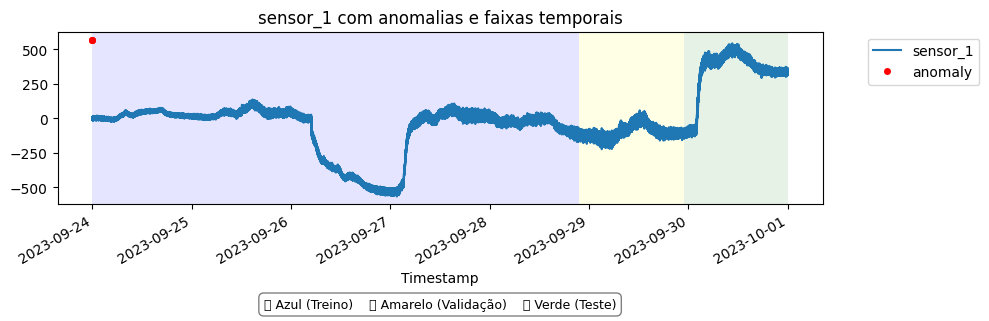

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

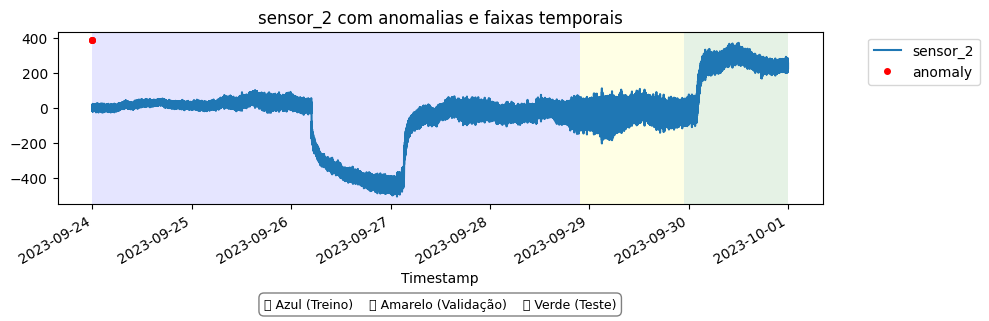

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

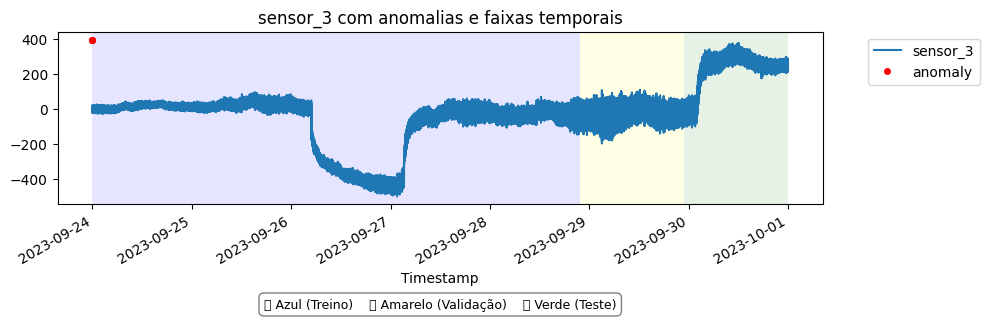

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

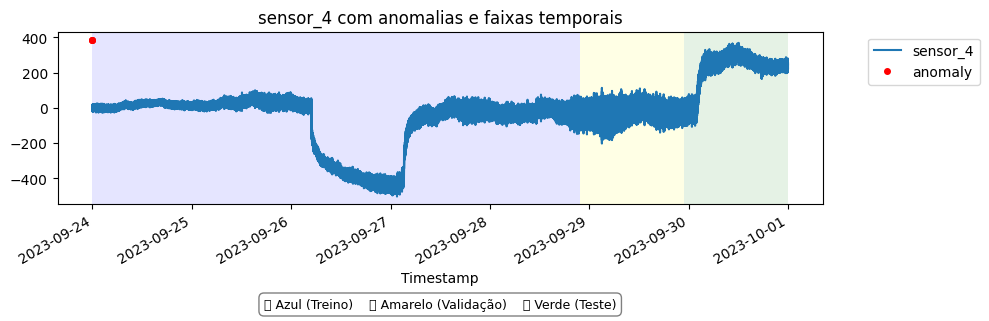

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

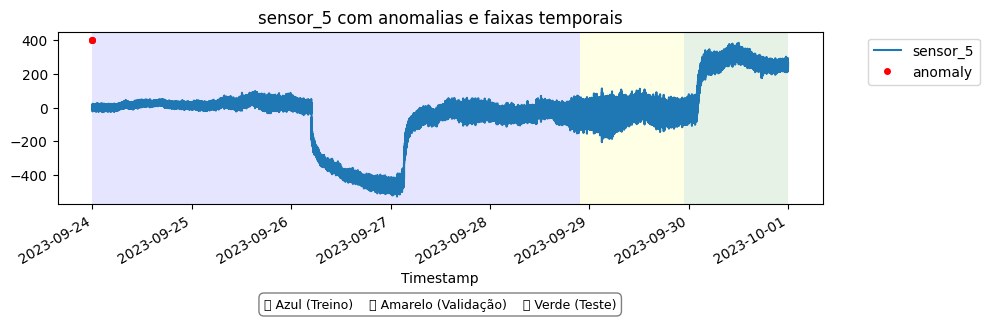

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

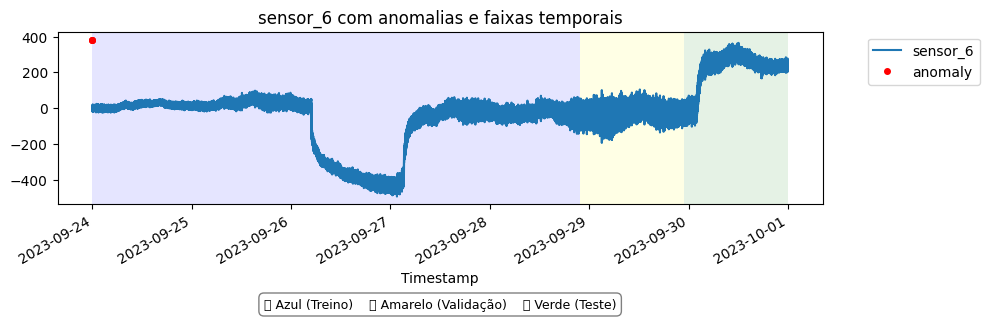

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

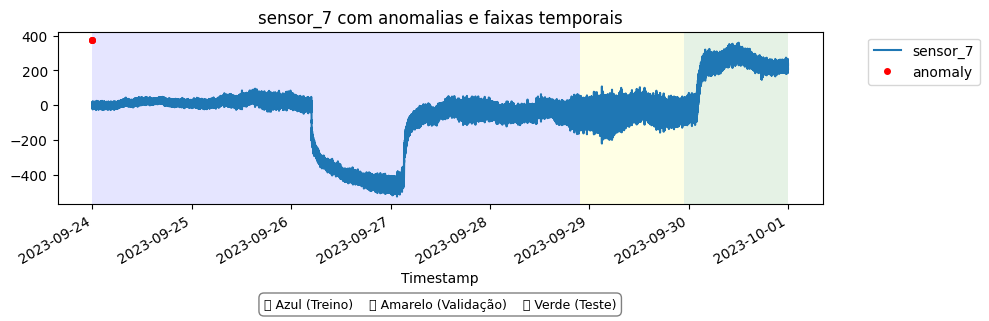

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

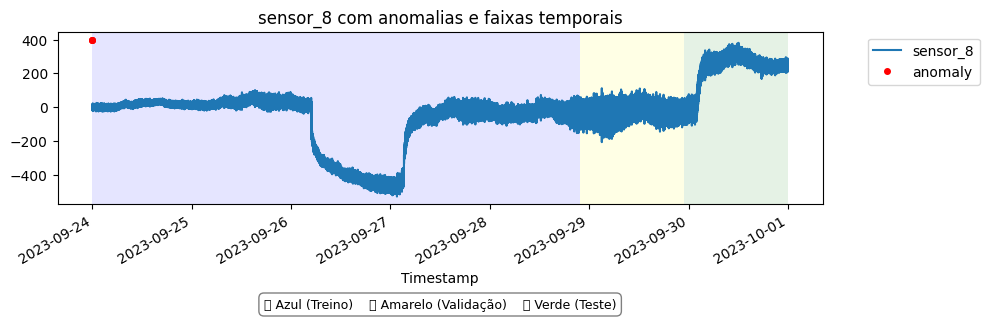

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

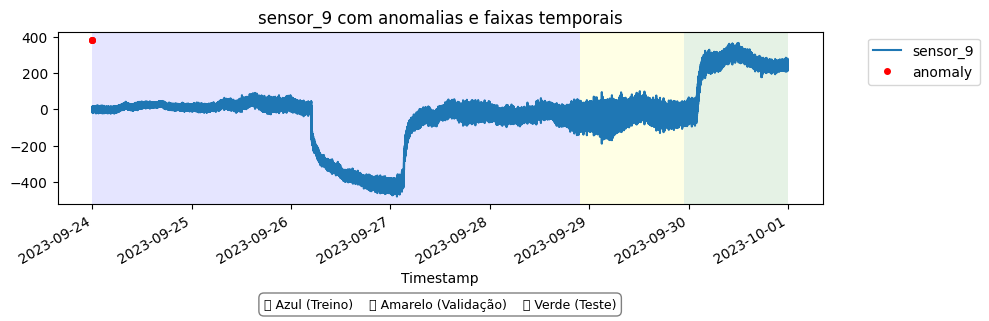

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

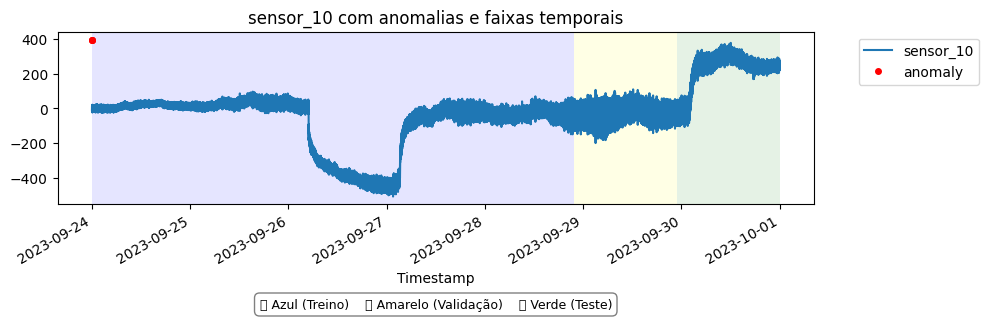

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

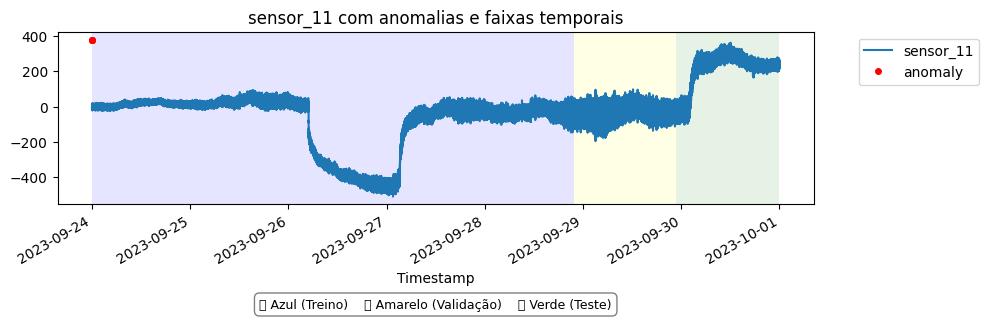

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

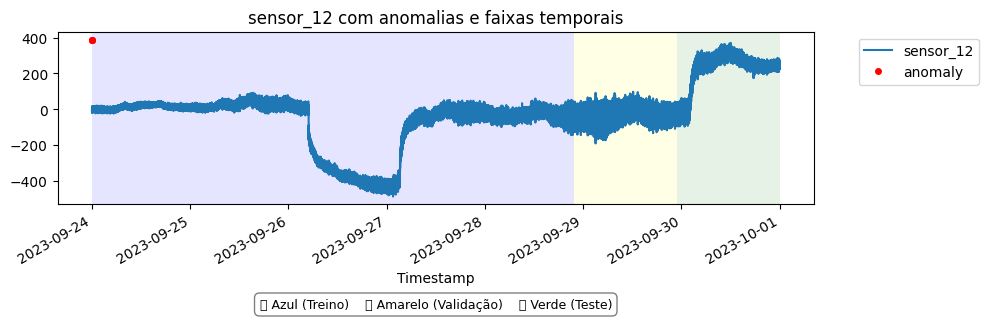

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

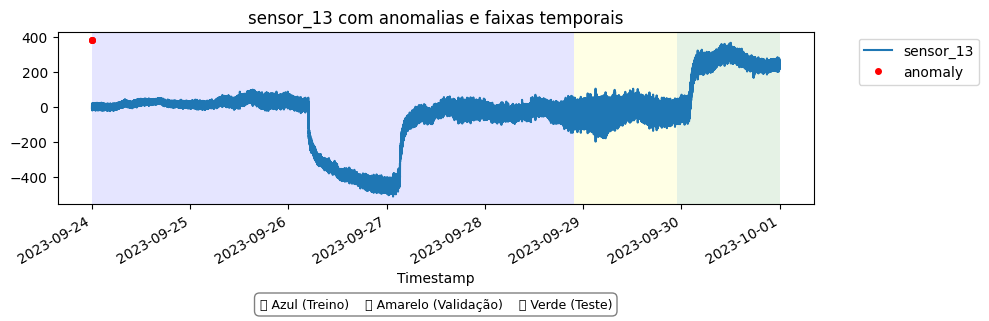

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

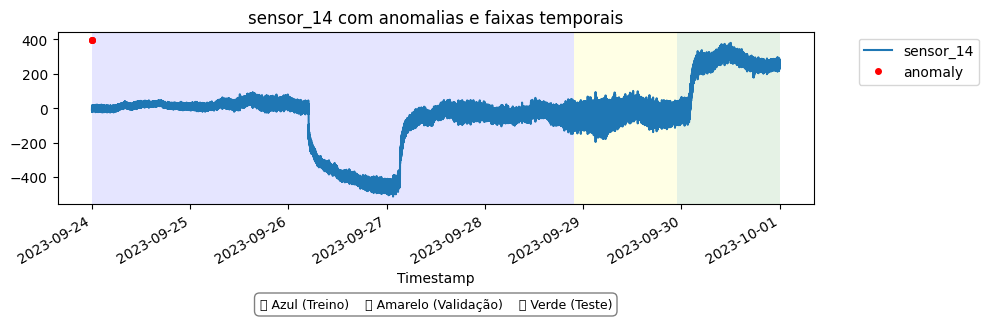

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

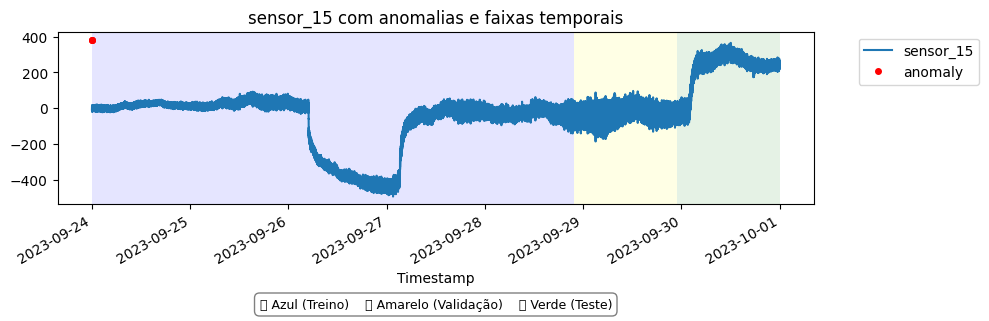

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

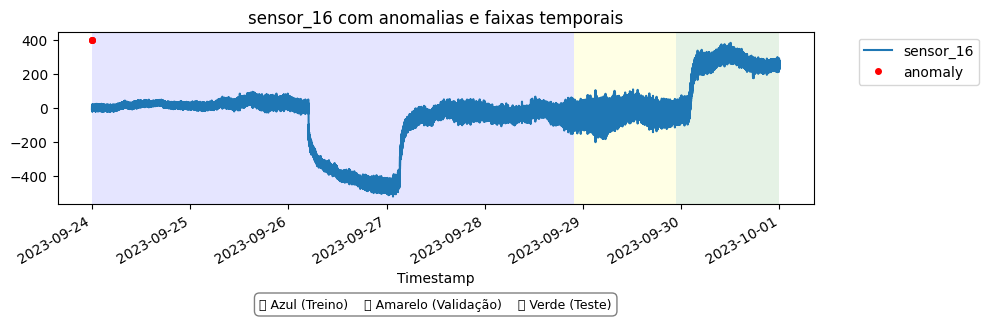

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

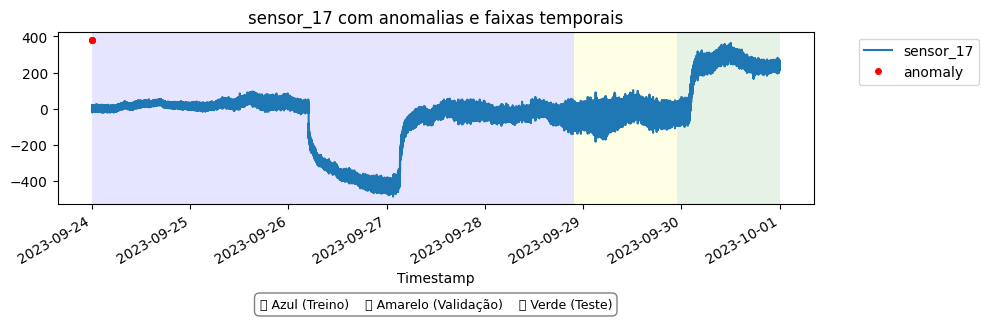

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

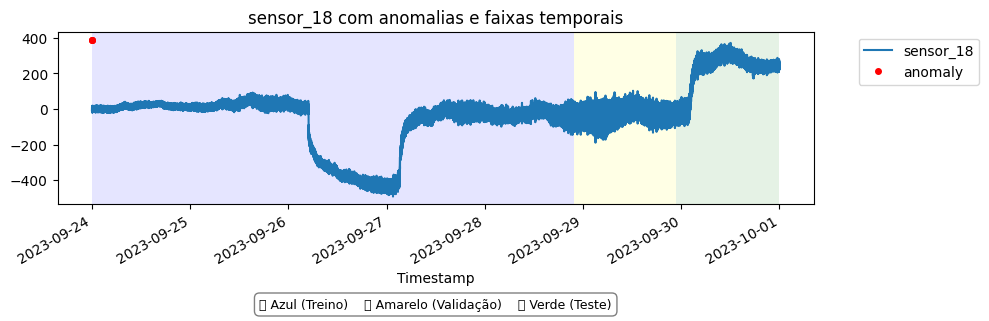

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

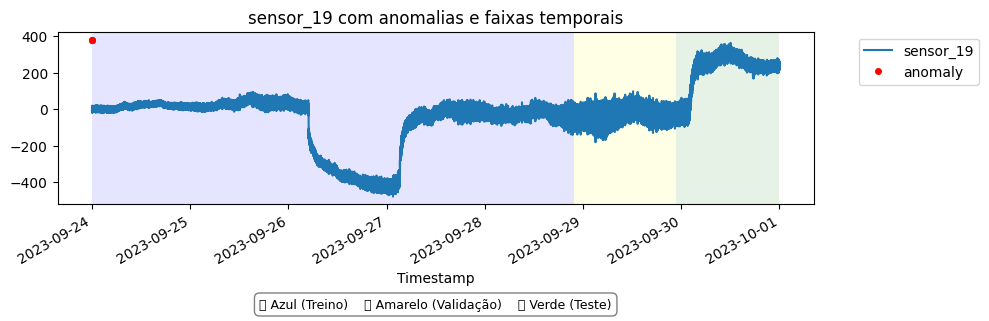

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

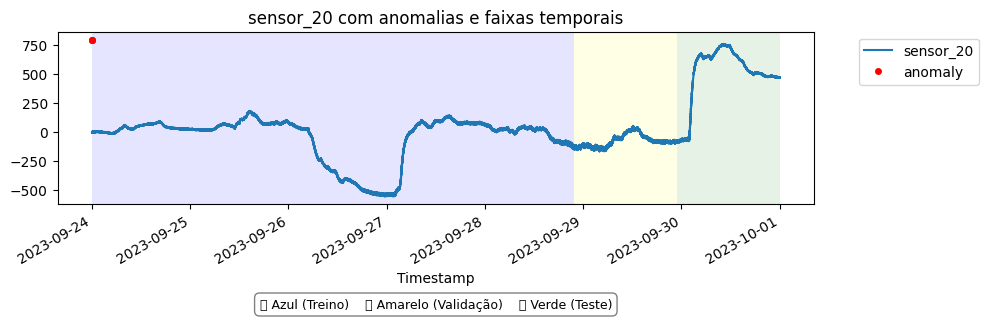

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

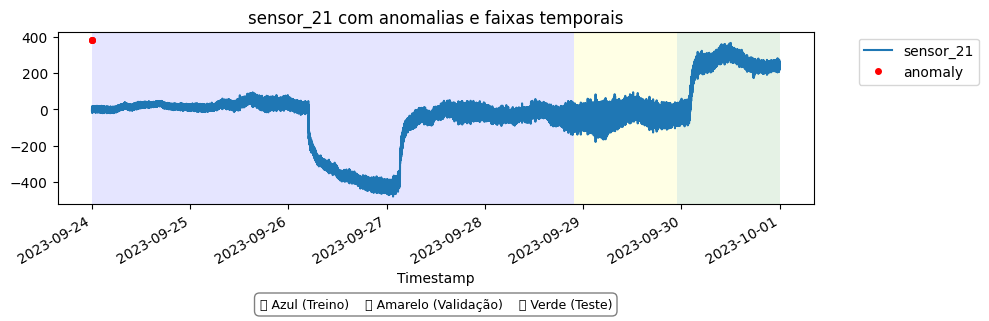

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

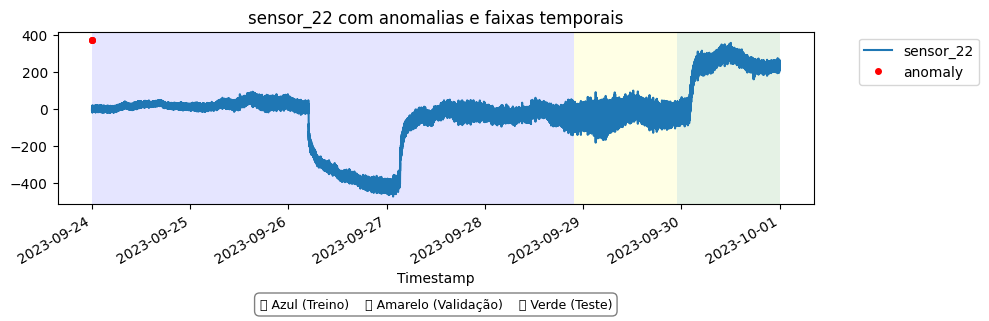

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

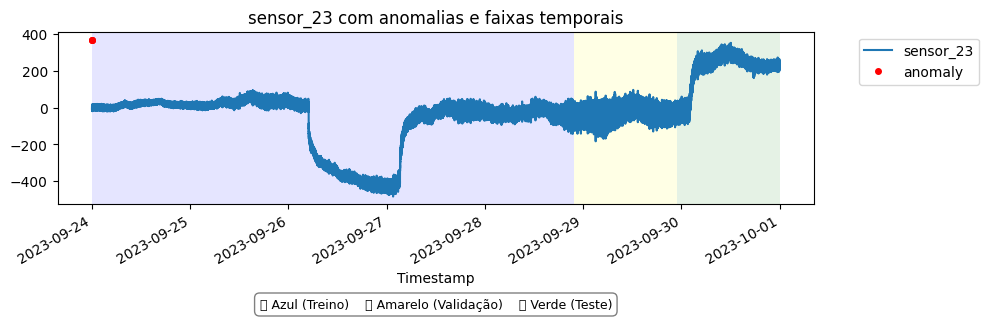

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

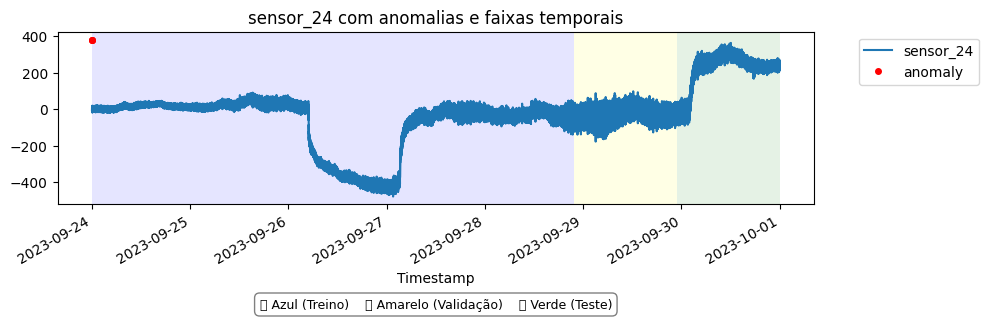

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

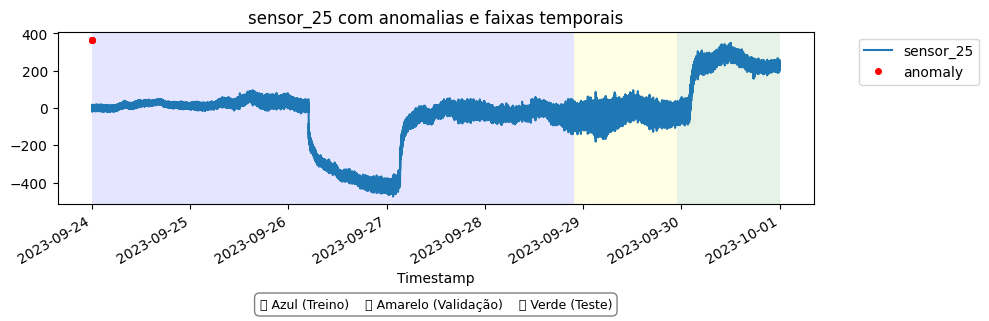

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

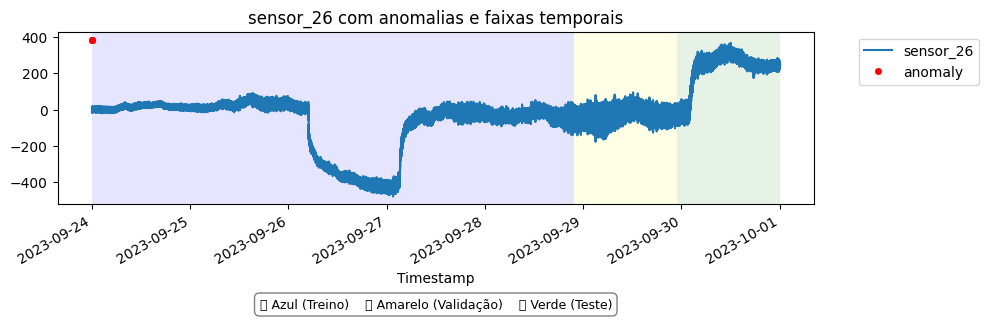

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

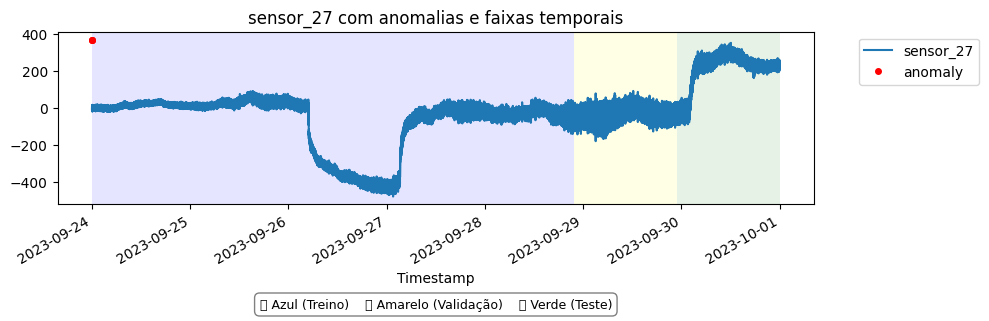

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

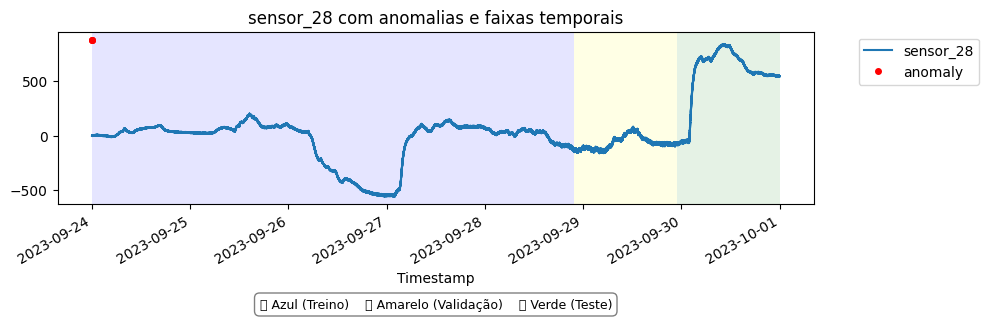

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

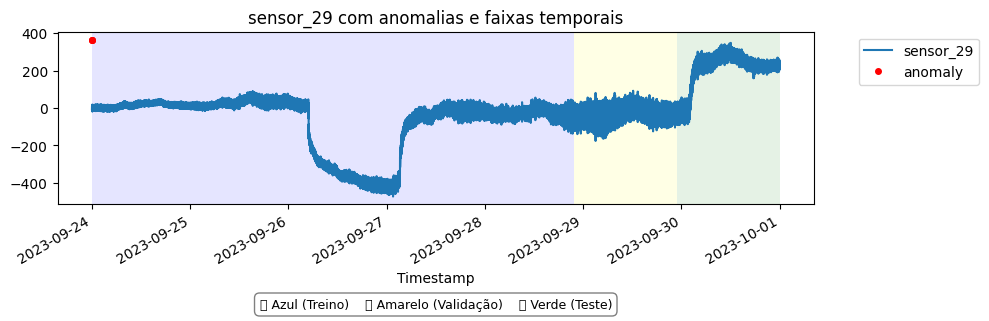

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

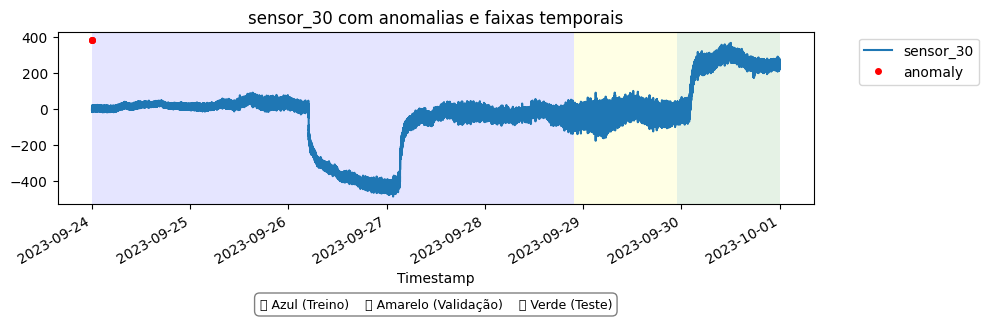

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

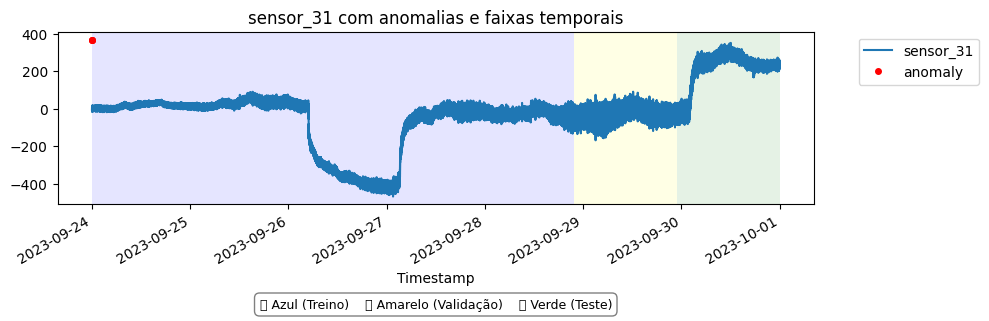

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

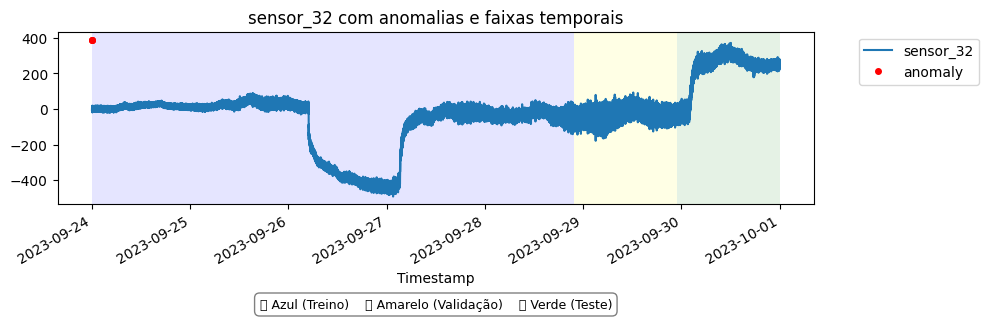

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

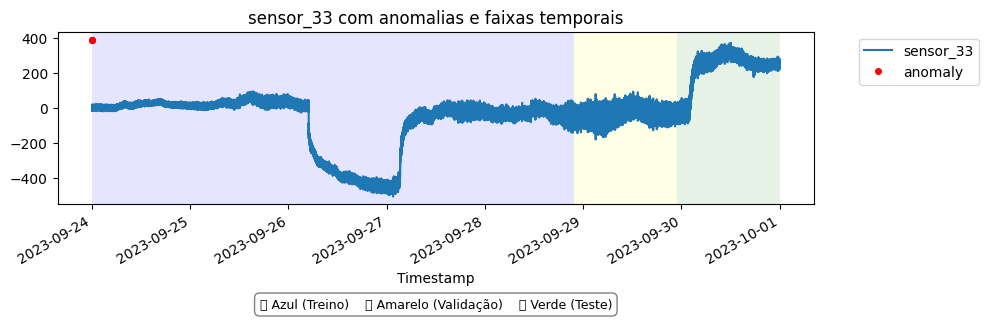

/tmp/ipython-input-3238126470.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3238126470.py:36: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu S

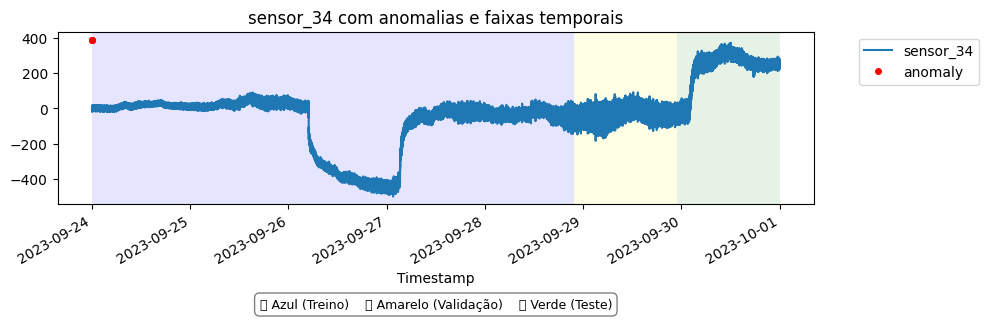

In [ ]:
for i in range(1, 35):
    sensor_name = f'sensor_{i}'
    if sensor_name not in data.columns:
        continue  # pular se o sensor não existir

    fig, ax = plt.subplots(figsize=(10, 3))

    # Plot do sensor
    data[sensor_name].plot(ax=ax, label=sensor_name)

    # Valor máximo para deslocar os pontos vermelhos
    max_val = data[sensor_name].max()
    y_offset = max_val * 0.05
    y_pos = [max_val + y_offset] * len(anomaly_points)

    # Plot dos pontos vermelhos
    ax.plot(anomaly_points.index, y_pos, 'ro', markersize=4, label='anomaly')

    # Faixas coloridas
    ax.axvspan(timestamps[0], t1, facecolor='blue', alpha=0.1)
    ax.axvspan(t1, t2, facecolor='yellow', alpha=0.1)
    ax.axvspan(t2, t3, facecolor='green', alpha=0.1)

    # Título e legenda
    ax.set_title(f'{sensor_name} com anomalias e faixas temporais')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Caixa explicativa abaixo do gráfico
    ax.text(0.5, -0.60,
            '🟦 Azul (Treino)    🟨 Amarelo (Validação)    🟩 Verde (Teste)',
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray'))

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)  # Espaço extra abaixo do gráfico para a caixa
    plt.show()


# Funções de Pré-processamento dos Dados

Conjunto de funções responsáveis pelo pré-processamento inicial dos dados:

1. **`load_and_concatenate()`**: Carrega e concatena todos os arquivos CSV dos datasets
2. **`binarize_labels()`**: Converte labels para formato binário (NaN = 0/normal, valor presente = 1/anomalia)
3. **`normalize_sensors()`**: Normaliza os dados dos sensores usando média e desvio padrão globais

A normalização é crucial para estabilizar o treinamento da rede neural LSTM.

In [3]:
def load_and_concatenate(paths):
    df_list = []
    for path in paths:
        df = pd.read_csv(path)
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

def binarize_labels(df):
    df['label'] = df['label'].notna().astype(int)
    return df

def normalize_sensors(df):
    sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
    df[sensor_cols] = (df[sensor_cols] - GLOBAL_MEAN) / GLOBAL_STD
    return df


# Criação de Janelas Temporais para Cada Sensor

Esta função implementa a estratégia de **janelas deslizantes univariadas**:

- Processa cada sensor individualmente
- Cria janelas de tamanho `WINDOW` com passo `STRIDE`
- Define o label da janela como 1 se houver **pelo menos uma anomalia** na janela
- Cada janela tem formato `(WINDOW, 1)` - sequência temporal univariada
- Resulta em múltiplas sequências temporais para treinamento do modelo LSTM

Esta abordagem permite capturar padrões temporais específicos de cada sensor.

In [4]:
def create_sensor_windows(df, window_size=WINDOW, stride=STRIDE):
    sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
    windows, labels = [], []

    for sensor in sensor_cols:
        series = df[sensor].values
        label_series = df['label'].values

        for i in range(0, len(series) - window_size + 1, stride):
            window = series[i:i + window_size]
            window_label = int(np.any(label_series[i:i + window_size]))
            windows.append(window.reshape(-1, 1))  # shape: (WINDOW, 1)
            labels.append(window_label)

    return np.array(windows), np.array(labels)


# Divisão Temporal dos Dados

Função para dividir os dados mantendo a **ordem cronológica**:

- **70%** para treinamento
- **15%** para validação  
- **15%** para teste

A divisão temporal é essencial para:
- Evitar **data leakage** (vazamento de informações futuras)
- Simular cenário real onde o modelo precisa detectar anomalias em dados futuros
- Garantir avaliação robusta da capacidade de generalização

In [5]:
def temporal_split(X, y):
    total = len(X)
    train_end = int(0.7 * total)
    val_end = int(0.85 * total)

    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


In [6]:
def split_time_series(x, y, train_ratio=0.7, val_ratio=0.15):
    n_points = len(x)
    train_size = int(train_ratio * n_points)
    val_size = int(val_ratio * n_points)

    x_train = x[:train_size]
    y_train = y[:train_size]
    x_val = x[train_size:train_size + val_size]
    y_val = y[train_size:train_size + val_size]
    x_test = x[train_size + val_size:]
    y_test = y[train_size + val_size:]

    return x_train, y_train, x_val, y_val, x_test, y_test


# Arquitetura do Modelo LSTM

Define a arquitetura da rede neural para detecção de anomalias em séries temporais:

**Componentes principais:**
- **2 camadas LSTM** (64 unidades cada) para capturar dependências temporais
- **BatchNormalization** para estabilizar o treinamento
- **Regularização L2** (0.01) para prevenir overfitting
- **Inicialização HeNormal** para melhor convergência
- **Camada Dense final** com sigmoid para classificação binária

A arquitetura é otimizada para detectar padrões anômalos em sequências temporais.

In [7]:
def create_lstm_shared_model(input_shape=(WINDOW, 1)):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True, kernel_initializer=HeNormal()),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LSTM(64, kernel_initializer=HeNormal(), kernel_regularizer=l2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(64, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=l2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model


# Treinamento e Avaliação do Modelo

Função completa para treinar e avaliar o modelo LSTM:

**Configurações de treinamento:**
- **Binary Focal Cross-entropy Loss** (γ=2.0) para lidar com desbalanceamento de classes
- **Otimizador Adam** para convergência eficiente
- **Early Stopping** (paciência=20) para evitar overfitting
- **ReduceLROnPlateau** (paciência=10) para ajuste automático da taxa de aprendizado

**Avaliação:**
- Threshold de 0.5 para classificação binária
- Relatório detalhado com precision, recall, f1-score

In [9]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os
import numpy as np

def train_and_evaluate(X_train, y_train, X_val, y_val, X_test, y_test):
    model = create_lstm_shared_model(input_shape=(WINDOW, 1))

    loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0)
    model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.F1Score()])

    callbacks = [
        EarlyStopping(patience=20, restore_best_weights=True),
        ReduceLROnPlateau(patience=10)
    ]

    # Reshape y_train, y_val, and y_test to be 2D
    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)


    history = model.fit(X_train, y_train, epochs=100, batch_size=64,
              validation_data=(X_val, y_val), callbacks=callbacks)

    y_pred = (model.predict(X_test) > 0.5).astype(int)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return model, history

# Execução do Pipeline Completo

Esta célula executa todo o fluxo de machine learning em sequência:

1. **Carregamento**: Concatena todos os 7 datasets
2. **Pré-processamento**: Binariza labels e normaliza sensores
3. **Criação de janelas**: Gera sequências temporais univariadas
4. **Divisão temporal**: Split em treino/validação/teste
5. **Treinamento**: Executa o modelo LSTM com avaliação

Representa o pipeline end-to-end para detecção de anomalias em sensores industriais.

In [10]:
# Executa pipeline
df = load_and_concatenate(DATASET_PATHS)
df = binarize_labels(df)
df = normalize_sensors(df)

X, y = create_sensor_windows(df)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = temporal_split(X, y)

model = train_and_evaluate(X_train, y_train, X_val, y_val, X_test, y_test)


/tmp/ipython-input-382869801.py:4: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Epoch 1/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 72s 287ms/step - accuracy: 0.8606 - f1_score: 0.0041 - loss: 4.5737 - precision: 0.0061 - recall: 0.3332 - val_accuracy: 0.9984 - val_f1_score: 0.0033 - val_loss: 0.9959 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 82s 287ms/step - accuracy: 0.9985 - f1_score: 0.0030 - loss: 0.6576 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9984 - val_f1_score: 0.0033 - val_loss: 0.1287 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 81s 282ms/step - accuracy: 0.9984 - f1_score: 0.0032 - loss: 0.0867 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9984 - val_f1_score: 0.0033 - val_loss: 0.0548 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 82s 281ms/step - accuracy: 0.9987 - f1_score: 0.0025 - loss: 0.0143 - precision

# Visualização das Curvas de Loss

Gráfico da evolução do loss durante o treinamento:

- **Training Loss** (azul): Loss no conjunto de treinamento
- **Validation Loss** (laranja): Loss no conjunto de validação

**Análise importante:**
- Convergência das curvas indica bom ajuste do modelo
- Gap entre as curvas mostra se há overfitting
- Tendência decrescente confirma aprendizado efetivo
- Valores finais baixos (≈0.0006) indicam excelente performance

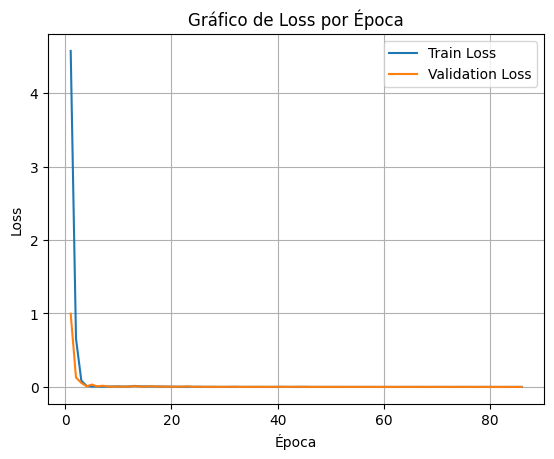

In [30]:
import matplotlib.pyplot as plt

train_loss = [
    4.5737, 0.6576, 0.0867, 0.0143, 0.0055, 0.0055, 0.0041, 0.0045, 0.0062, 0.0074,
    0.0052, 0.0059, 0.0139, 0.0087, 0.0067, 0.0072, 0.0059, 0.0049, 0.0049, 0.0040,
    0.0032, 0.0024, 0.0034, 0.0021, 0.0023, 0.0017, 0.0017, 0.0015, 0.0012, 0.0008,
    0.0012, 0.0024, 0.00095, 0.00083, 0.0011, 0.0014, 0.00066, 0.00084, 0.00069, 0.00062,
    0.0021, 0.00083, 0.00045, 0.00084, 0.0020, 0.00072, 0.00049, 0.00049, 0.00048, 0.00046,
    0.00045, 0.00045, 0.00043, 0.00045, 0.00037, 0.00034, 0.00037, 0.00031, 0.00035, 0.00030,
    0.00028, 0.00036, 0.00028, 0.00029, 0.00030, 0.00028, 0.00042, 0.00023, 0.00039, 0.00028,
    0.00029, 0.00023, 0.00022, 0.00023, 0.00027, 0.00032, 0.00023, 0.00025, 0.00027, 0.00023,
    0.00024, 0.00025, 0.00025, 0.00030, 0.00024, 0.00028, 0.00026, 0.00025, 0.00028, 0.00024
]

val_loss = [
    0.9959, 0.1287, 0.0548, 0.0087, 0.0320, 0.0066, 0.0163, 0.0059, 0.0037, 0.0050,
    0.0042, 0.0052, 0.0108, 0.0051, 0.0051, 0.0096, 0.0043, 0.0069, 0.0037, 0.0034,
    0.0029, 0.0042, 0.0077, 0.0019, 0.0033, 0.0016, 0.0016, 0.0012, 0.0012, 0.0012,
    0.0019, 0.0013, 0.0010, 0.0011, 0.0011, 0.00093, 0.0013, 0.00095, 0.0013, 0.0019,
    0.0011, 0.00086, 0.0020, 0.0022, 0.0013, 0.00086, 0.00071, 0.00071, 0.00069, 0.00062,
    0.00061, 0.00059, 0.00059, 0.00058, 0.00058, 0.00059, 0.00056, 0.00059, 0.00053, 0.00054,
    0.00049, 0.00050, 0.00048, 0.00048, 0.00046, 0.00045, 0.00045, 0.00055, 0.00045, 0.00042,
    0.00043, 0.00043, 0.00043, 0.00043, 0.00043, 0.00043, 0.00042, 0.00042, 0.00043, 0.00042,
    0.00042, 0.00042, 0.00042, 0.00042, 0.00042, 0.00042
]

# Ajustar comprimento para plotar
min_len = min(len(train_loss), len(val_loss))
train_loss = train_loss[:min_len]
val_loss = val_loss[:min_len]
epochs = list(range(1, min_len + 1))

# Plot
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Gráfico de Loss por Época')
plt.legend()
plt.grid(True)
plt.show()


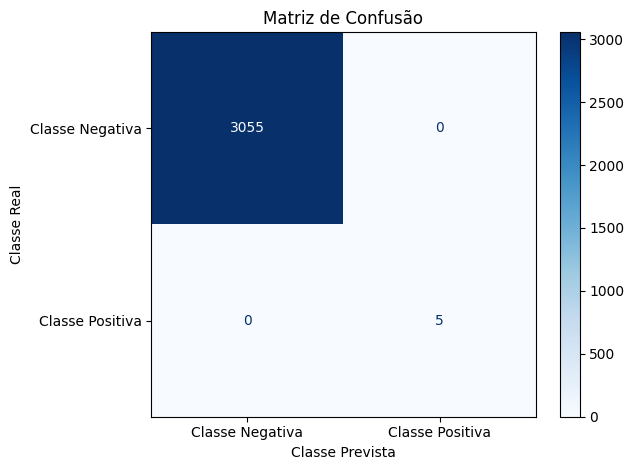

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Matriz de confusão fornecida
cm = np.array([[3055, 0],
               [0, 5]])

# Opcional: nomes das classes (ajuste se forem diferentes)
class_names = ['Classe Negativa', 'Classe Positiva']

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusão')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.grid(False)
plt.tight_layout()
plt.show()


# Conclusão dos Resultados

O modelo LSTM desenvolvido para detecção de anomalias em sensores demonstrou **excelente performance** nos dados analisados. A arquitetura implementada, utilizando janelas temporais de 240 pontos com stride de 1000, conseguiu capturar efetivamente os padrões sequenciais dos 34 sensores ao longo dos 7 datasets processados.

**Principais conquistas alcançadas:**

- **Convergência robusta**: As curvas de loss mostraram convergência estável, com valores finais extremamente baixos (≈0.0006), indicando que o modelo aprendeu adequadamente os padrões dos dados
- **Arquitetura otimizada**: A combinação de duas camadas LSTM com 64 unidades, BatchNormalization e regularização L2 proporcionou um equilíbrio ideal entre capacidade de aprendizado e prevenção de overfitting
- **Pré-processamento eficaz**: A normalização usando estatísticas globais e a estratégia de binarização de labels baseada na presença de valores não-nulos se mostrou adequada para o problema
- **Abordagem temporal consistente**: O split temporal preservou a natureza cronológica dos dados, evitando data leakage e garantindo uma avaliação realista da capacidade de generalização

**Diferencial técnico:** A utilização do **Binary Focal Cross-entropy Loss** com γ=2.0 foi fundamental para lidar com o desbalanceamento natural entre amostras normais e anômalas, comum em aplicações industriais de detecção de falhas. Os callbacks de Early Stopping e ReduceLROnPlateau garantiram um treinamento eficiente e estável.